# Creating Landsat Dataset

Notebook contains code for Landsat dataset extraction

In [ ]:
%pip install sentinelhub

### Authentification Landsat

In [ ]:
from sentinelhub import SHConfig

import os
CLIENT_ID_LANDSAT = os.getenv("CLIENT_ID_LANDSAT")
CLIENT_SECRET_LANDSAT = os.getenv("CLIENT_SECRET_LANDSAT")
INSTANCE_ID_LANDSAT = os.getenv("INSTANCE_ID_LANDSAT")

config_mirta = SHConfig(
    sh_client_id=CLIENT_ID_LANDSAT,
    sh_client_secret= CLIENT_SECRET_LANDSAT,
)

config_mirta.instance_id = INSTANCE_ID_LANDSAT

if not config_mirta.sh_client_id or not config_mirta.sh_client_secret:
    print("Warning! To use Process API, please provide the credentials (OAuth client ID and client secret).")

### Imports

In [2]:
import datetime
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

from sentinelhub import (
    CRS,
    BBox,
    DataCollection,
    DownloadRequest,
    MimeType,
    MosaickingOrder,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    bbox_to_dimensions,
)
import json
from shapely.geometry import shape
import rasterio

from shapely.geometry import Polygon, Point, box
import random

from sentinelhub import WebFeatureService, BBox, CRS, DataCollection, SHConfig
from datetime import datetime
from tqdm import tqdm

In [ ]:
if not os.path.exists("/content/drive"):
    drive.mount("/content/drive")

In [3]:
project_root = os.getenv('PROJECT_ROOT_PATH')
data_save_path = os.getenv('DATA_PATH')
geojson_file_general = os.getenv('GEOJSON_GENERAL')
geojson_file_waterbodies = os.getenv('GEOJSON_WATERBODIES')
geojson_file_boris24 = os.getenv('GEOJSON_BORIS24')
geojson_file_germany21 = os.getenv('GEOJSON_GERMANY21')
geojson_file_germany24 = os.getenv('GEOJSON_GERMANY24')

# Add the project root path to the system path
sys.path.append(project_root)

#necessary imports
from scripts.data_preparation.dataset_creation_landsat import *

## Generating BBox

### Generating Random Point and BBox in Specified Polygon


In [ ]:
AOI_Polygon = read_get_aoi_polygon(geojson_file_general)

## Landsat Image Download and Transformation

In [ ]:

def get_landsat(bbox, size, data_folder, time_interval=("2023-9-7", "2023-9-7"), data_collection=DataCollection.LANDSAT_OT_L2, config=config_mirta):
    """
    Fetches and saves Sentinel-2 L2A data using the specified parameters.

    Args:
        bbox (BBox): Bounding box of the area of interest.
        size (tuple): Size of the output image (width, height).
        data_folder (str): Path to the folder where the data will be saved.
        time_interval (tuple, optional): Start and end date of the time interval. Defaults to ("2023-12-01", "2023-12-31").
        data_collection (DataCollection, optional): Sentinel Hub data collection. Defaults to DataCollection.SENTINEL2_L2A.
        config (SHConfig, optional): Sentinel Hub configuration object. Defaults to config.

    Returns:
        SentinelHubRequest: Sentinel Hub request object.
    """

    evalscript_all_bands = """
        //VERSION=3

        function setup() {
          return {
            input: [{
              bands: ["B02", "B03", "B04", "B05", "B06", "B10", "dataMask"],
              units: ["REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "SURFACE_TEMPERATURE", "REFLECTANCE"]
            }],
            output: {
              bands: 7,
              sampleType: "AUTO"
            }
          };
        }

        function evaluatePixel(sample) {
          return [
            sample.B02, // Blue
            sample.B03, // Green
            sample.B04, // Red
            sample.B05, // NIR
            sample.B06, // SWIR 1
            sample.B10, // Thermal
            sample.dataMask // Valid pixel mask
          ];
        }

    """

    request_all_bands = SentinelHubRequest(
        data_folder=data_folder,
        evalscript=evalscript_all_bands,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=data_collection,
                time_interval=time_interval,
                # mosaicking_order=MosaickingOrder.LEAST_CC,
                # maxcc = 0.5
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=size,
        config=config_mirta,
    )

    return request_all_bands

In [ ]:
# get Landsat cloud water mask as a Layer in the Sentinel hub configuration

def get_landsat_masks(bbox, size, data_folder, time_interval=("2023-9-7", "2023-9-7"), data_collection=DataCollection.LANDSAT_OT_L2, config=config_mirta):
    """
    Fetches and saves Landsat-2 L2A data using the specified parameters.

    Args:
        bbox (BBox): Bounding box of the area of interest.
        size (tuple): Size of the output image (width, height).
        data_folder (str): Path to the folder where the data will be saved.
        time_interval (tuple, optional): Start and end date of the time interval. Defaults to ("2023-12-01", "2023-12-31").
        data_collection (DataCollection, optional): Sentinel Hub data collection.
        config (SHConfig, optional): Sentinel Hub configuration object.

    Returns:
        SentinelHubRequest: Sentinel Hub request object.
    """

    evalscript = """
        //VERSION=3

        function setup() {
          return {
            input: ["B02", "B03", "B04", "B05", "B06", "B07", "B10"],
            output: { bands: 3 }
          };
        }

        function evaluatePixel(sample) {
          let ndsi = (sample.B03 - sample.B06) / (sample.B03 + sample.B06);
          let ndvi = (sample.B05 - sample.B04) / (sample.B05 + sample.B04);

          let isBright = sample.B02 > 0.2 && sample.B03 > 0.2 && sample.B04 > 0.2;
          let isCold = sample.B10 < 300;
          let isLowNDVI = ndvi < 0.2;
          let isHighNDSI = ndsi > 0.3;

          let isCloud = (isBright && isCold && isLowNDVI);
          let isWater = isHighNDSI;

          if (isCloud) {
            return [1, 0, 0]; // Red for cloud
          } else if (isWater) {
            return [0, 0, 1]; // Blue for water
          } else {
            return [0, 0, 0]; // Black
          }
        }

    """

    request_all_bands = SentinelHubRequest(
        data_folder=data_folder,
        evalscript=evalscript,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=data_collection,
                time_interval=time_interval,
                # mosaicking_order=MosaickingOrder.LEAST_CC,
                # maxcc = 0.5
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox,
        size=size,
        config=config_mirta,
    )

    return request_all_bands

### Main Landsat

In [ ]:
def download_landsat_image_mask(quarter,num_images_per_q, data_collection = DataCollection.LANDSAT_OT_L2):
  #time_dict = {'Q1':('2024-01-01','2024-03-31'),
   #                     'Q2':('2024-04-01','2024-06-30'),
   #                    'Q3':('2024-07-01','2024-09-30'),
   #                    'Q4':('2024-10-01','2024-12-31'),
   #                    'flood_13_09_to_16_09':('2024-09-13','2024-09-16')
   #                     }

  # flood events
  time_dict = {'germany24':('2024-05-30','2024-06-08'),
               'germany21':('2021-07-14','2021-08-05'),
               'boris24':('2024-09-09','2024-09-30'),
               'saarland24':('2024-05-17','2024-06-17'),
               }

  quarters_time_dict = {quarter:time_dict[quarter]}

  data_path = sentinel2_path = os.path.join(data_save_path, 'LANDSAT')  

  #geojson file
  geojson_file = geojson_file_general

  AOI_Polygon = read_get_aoi_polygon(geojson_file)


  SIZE = (684, 684)
  img_counter = 0  # to number folders sequentially


  for quarter in quarters_time_dict:
    #data_folder = f'waterbodies_data_{quarter}_2024_raw'
    #mask_folder = f'waterbodies_data_{quarter}_2024_masks'

    # flood events
    data_folder = f'data_{quarter}_2024_raw'
    mask_folder = f'data_{quarter}_2024_masks'

    while(num_images_per_q > 0):
      from_date = quarters_time_dict[quarter][0]
      to_date = quarters_time_dict[quarter][1]
      maxcc = 0.5

      random_bbox = generate_random_bbox(AOI_Polygon, bbox_size=0.3)

      list_of_available_times =  tile_at_min_cc_landsat(random_bbox,from_date,to_date,data_collection=DataCollection.LANDSAT_OT_L2,cloud_coverage_max=maxcc,config=config_mirta)

      while len(list_of_available_times)==0 :
        random_bbox = generate_random_bbox(AOI_Polygon, bbox_size=0.3)
        list_of_available_times =  tile_at_min_cc_landsat(random_bbox,from_date,to_date,data_collection=DataCollection.LANDSAT_OT_L2,cloud_coverage_max=maxcc,config=config_mirta)

      date_of_image = list_of_available_times[ random.randint(0, len(list_of_available_times) - 1)]

      folder_suffix = f"{quarter}_{img_counter:02d}_{random.randint(1000, 9999)}"
      raw_folder_path = os.path.join(data_path, data_folder, folder_suffix)
      mask_folder_path = os.path.join(data_path, mask_folder, folder_suffix)

      image_to_save = get_landsat(
          random_bbox, SIZE, raw_folder_path,
          time_interval=(date_of_image, date_of_image),
          data_collection=data_collection, config=config_mirta
      )


      image_data = image_to_save.get_data()
      data_mask = image_data[-1]

      nodata_percentage = np.sum(data_mask == 0) / data_mask.size * 100


      #Calculate NoData percentage
      print(f"Percentage of NoData pixels: {nodata_percentage:.2f}%")

      if nodata_percentage > 10:
          print("Skipping image due to too many NoData pixels.")
          continue  # Skip this image and go to the next iteration

      generated_mask = get_landsat_masks(random_bbox, SIZE, mask_folder_path, time_interval=(date_of_image, date_of_image), data_collection=data_collection, config=config_mirta)

      mask_data = generated_mask.get_data()

      cloud_band = mask_data[0]  # red channel = cloud
      cloud_pixels = (cloud_band == 255)
      cloud_coverage = np.count_nonzero(cloud_pixels) / (cloud_band.shape[0] * cloud_band.shape[1]) * 100

      #cloud_coverage = np.sum(cloud_band == 255) / cloud_band.size * 100
      print(f" Cloud %: {cloud_coverage:.2f}%")

      if cloud_coverage > 40:
          print("Skipping due to high cloud cover")
          continue


      num_images_per_q = num_images_per_q - 1
      img_counter += 1

      image_to_save.save_data()
      generated_mask.save_data()

      print(f"Saved {folder_suffix}")



In [ ]:
random.seed(2024)
download_landsat_image_mask('germany24', 10)

In [ ]:
random.seed(202409)
download_landsat_image_mask('boris24', 12)

In [ ]:
random.seed(2021)
download_landsat_image_mask('germany21', 10)

In [ ]:
seed_plan_2022 = {
    'Q1': 1234,
    'Q2': 5678,
    'Q3': 9101,
    'Q4': 2022
}


In [ ]:
for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
    random.seed(seed_plan_2022[quarter])
    download_landsat_image_mask(quarter, 40)  # 40 images

In [ ]:
# waterbodies 2022
for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
    random.seed(seed_plan_2022[quarter])
    download_landsat_image_mask(quarter, 10)

In [ ]:
seed_plan_2023 = {
    'Q1': 42,
    'Q2': 123,
    'Q3': 7,
    'Q4': 2023
}

In [ ]:
# waterbodies 2023
for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
    random.seed(seed_plan_2023[quarter])
    download_landsat_image_mask(quarter, 10)

In [ ]:
for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
    random.seed(seed_plan_2023[quarter])
    download_landsat_image_mask(quarter, 40)  # 40 images


In [ ]:
seed_plan_2024 = {
    'Q1': 88,
    'Q2': 99,
    'Q3': 100,
    'Q4': 77
}

In [ ]:
for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
    random.seed(seed_plan_2024[quarter])
    download_landsat_image_mask(quarter, 10)

In [ ]:
for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
    random.seed(seed_plan_2024[quarter])
    download_landsat_image_mask(quarter, 40)

In [ ]:
# check the masks
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

from glob import glob

import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Updated folder paths
raw_folder = '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q4_2024_raw'
mask_folder = '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q4_2024_masks'

# Get list of all subfolders (with informative names)
raw_informative_folders = sorted(os.listdir(raw_folder))
mask_informative_folders = sorted(os.listdir(mask_folder))

# Loop through matching folders
for raw_info, mask_info in zip(raw_informative_folders, mask_informative_folders):
    raw_info_path = os.path.join(raw_folder, raw_info)
    mask_info_path = os.path.join(mask_folder, mask_info)

    # Each contains a subfolder with a random ID
    raw_subfolders = os.listdir(raw_info_path)
    mask_subfolders = os.listdir(mask_info_path)

    if not raw_subfolders or not mask_subfolders:
        print(f"Skipping {raw_info} due to missing inner folders.")
        continue

    raw_tiff_path = os.path.join(raw_info_path, raw_subfolders[0], 'response.tiff')
    mask_tiff_path = os.path.join(mask_info_path, mask_subfolders[0], 'response.tiff')

    if not os.path.exists(raw_tiff_path) or not os.path.exists(mask_tiff_path):
        print(f"Missing TIFFs in {raw_info}")
        continue

    # Read raw image
    with rasterio.open(raw_tiff_path) as raw_src:
        raw_img = raw_src.read([3, 2, 1])  # RGB (B04, B03, B02)
        raw_img = np.transpose(raw_img, (1, 2, 0))
        raw_img = raw_img.astype(np.float32)
        raw_img /= raw_img.max()

    # Read mask image
    with rasterio.open(mask_tiff_path) as mask_src:
        mask_img = mask_src.read()
        mask_img = np.transpose(mask_img, (1, 2, 0))

    # Plot side by side
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(raw_img)
    axs[0].set_title(f"Raw Image - {raw_info}")
    axs[0].axis('off')

    axs[1].imshow(mask_img)
    axs[1].set_title(f"Mask - {mask_info}")
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()



### Check elevation and region to correct ice

In [ ]:
import rasterio
import requests
import numpy as np

def get_image_bbox(tiff_path):
    with rasterio.open(tiff_path) as src:
        bounds = src.bounds
        return bounds

def reverse_geocode(lat, lon):
    url = "https://nominatim.openstreetmap.org/reverse"
    params = {
        'format': 'jsonv2',
        'lat': lat,
        'lon': lon,
        'zoom': 8,
        'addressdetails': 1
    }
    response = requests.get(url, params=params, headers={"User-Agent": "GeoTIFF-Region-Finder"})
    if response.status_code == 200:
        data = response.json()
        return data.get('address', {}).get('state', 'Unknown')
    return "Unknown"

def get_max_elevation(bounds, samples=5):
    lats = np.linspace(bounds.bottom, bounds.top, samples)
    lons = np.linspace(bounds.left, bounds.right, samples)

    coords = [{"latitude": lat, "longitude": lon} for lat in lats for lon in lons]
    url = "https://api.open-elevation.com/api/v1/lookup"
    response = requests.post(url, json={"locations": coords})

    if response.status_code == 200:
        elevations = [loc['elevation'] for loc in response.json()['results']]
        return max(elevations)
    return None


tiff_path = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/response.tiff"

bounds = get_image_bbox(tiff_path)

center_lat = (bounds.top + bounds.bottom) / 2
center_lon = (bounds.left + bounds.right) / 2
region = reverse_geocode(center_lat, center_lon)
max_elev = get_max_elevation(bounds)

print(f"Image at ({center_lat:.5f}, {center_lon:.5f}) is located in: {region}")
print(f"Max Elevation: {max_elev} meters")



### Removing the wrongly classified ice and snow

Workflow:

1. Look through the images whose max. elevation > 1000m
2. If it is manually confirmed that the white is actually ice and snow and not cloud, then remove cloud pixels from the mask and correct it with the following logic:
  - ndsi > 0.4 - this is ice, so it becomes other
  - ndwi > 0.3 and ndsi < 0.4 - this is water
  

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def compute_and_plot_ndsi_ndwi(tiff_path):
    with rasterio.open(tiff_path) as src:
        # Read bands (Landsat order): B02, B03, B04, B05, B06, B10
        blue = src.read(1).astype(np.float32)
        green = src.read(2).astype(np.float32)
        red = src.read(3).astype(np.float32)
        nir = src.read(4).astype(np.float32)
        swir1 = src.read(5).astype(np.float32)

    # Normalize if values are uint8
    if blue.max() <= 255:
        blue /= 255.0
        green /= 255.0
        red /= 255.0
        nir /= 255.0
        swir1 /= 255.0

    # Compute indices
    ndsi = (green - swir1) / (green + swir1 + 1e-6)
    ndwi = (green - nir) / (green + nir + 1e-6)

    # RGB image
    rgb = np.clip(np.stack([red, green, blue], axis=-1), 0, 1)

    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].imshow(rgb)
    axs[0].set_title("Raw RGB Image")
    axs[0].axis('off')

    im1 = axs[1].imshow(ndsi, cmap='Blues', vmin=-1, vmax=1)
    axs[1].set_title("NDSI (Snow/Ice Index)")
    axs[1].axis('off')
    plt.colorbar(im1, ax=axs[1])

    im2 = axs[2].imshow(ndwi, cmap='Greens', vmin=-1, vmax=1)
    axs[2].set_title("NDWI (Water Index)")
    axs[2].axis('off')
    plt.colorbar(im2, ax=axs[2])

    plt.tight_layout()
    plt.show()

compute_and_plot_ndsi_ndwi("/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/response.tiff")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def correct_mask_ndsi_ndwi(raw_image_path, mask_path, output_path):
    # Load raw bands
    with rasterio.open(raw_image_path) as src:
        red   = src.read(3).astype(np.float32)  # B04
        green = src.read(2).astype(np.float32)  # B03
        blue  = src.read(1).astype(np.float32)  # B02
        nir   = src.read(4).astype(np.float32)  # B05
        swir1 = src.read(5).astype(np.float32)  # B06
        profile = src.profile

    if red.max() > 1:
        red /= 255.0
        green /= 255.0
        blue /= 255.0
        nir /= 255.0
        swir1 /= 255.0

    rgb = np.clip(np.stack([red, green, blue], axis=-1), 0, 1)

    # Compute indices
    ndsi = (green - swir1) / (green + swir1 + 1e-6)
    ndwi = (green - nir) / (green + nir + 1e-6)

    # Load mask
    with rasterio.open(mask_path) as msk_src:
        mask_rgb = msk_src.read().astype(np.uint8)
        mask_rgb = np.transpose(mask_rgb, (1, 2, 0))  # (H, W, 3)
        mask_profile = msk_src.profile

    mask = np.zeros(mask_rgb.shape[:2], dtype=np.uint8)
    mask[mask_rgb[:, :, 0] == 255] = 2  # Cloud
    mask[(mask_rgb[:, :, 2] == 255) & (mask != 2)] = 1  # Water

    original = mask.copy()

    is_ice = (ndsi > 0.4) & (ndwi < 0.3)
    is_water = (ndwi > 0.3) & (ndsi < 0.4)

    mask[is_ice] = 0
    mask[(original == 0) & is_water] = 1

    # Report changes
    removed_cloud = np.sum((original == 2) & (mask == 0))
    removed_water = np.sum((original == 1) & (mask == 0))
    added_water = np.sum((original == 0) & (mask == 1))

    print(f"Cloud pixels removed (ice):  {removed_cloud}")
    print(f"Water pixels removed (ice): {removed_water}")
    print(f"Water pixels added:          {added_water}")

    # Convert masks to RGB-style for visualization
    def mask_to_rgb(mask_arr):
        rgb_mask = np.zeros((*mask_arr.shape, 3), dtype=np.uint8)
        rgb_mask[mask_arr == 1, 2] = 255  # Blue: water
        rgb_mask[mask_arr == 2, 0] = 255  # Red: cloud
        return rgb_mask

    original_rgb = mask_to_rgb(original)
    corrected_rgb = mask_to_rgb(mask)

    # Save corrected mask
    corrected_rgb_to_save = np.transpose(corrected_rgb, (2, 0, 1))
    mask_profile.update(count=3, dtype='uint8')

    with rasterio.open(output_path, 'w', **mask_profile) as dst:
        dst.write(corrected_rgb_to_save)

    print(f"Corrected mask saved to: {output_path}")

    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].imshow(rgb)
    axs[0].set_title("Raw RGB Image")
    axs[0].axis('off')

    axs[1].imshow(original_rgb)
    axs[1].set_title("Original Mask (Red=Cloud, Blue=Water)")
    axs[1].axis('off')

    axs[2].imshow(corrected_rgb)
    axs[2].set_title("Corrected Mask (Red=Cloud, Blue=Water)")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()


✅ Cloud pixels removed (ice):  38636
✅ Water pixels removed (ice): 83879
✅ Water pixels added:          38
💾 Corrected mask saved to: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2//waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/response.tiff


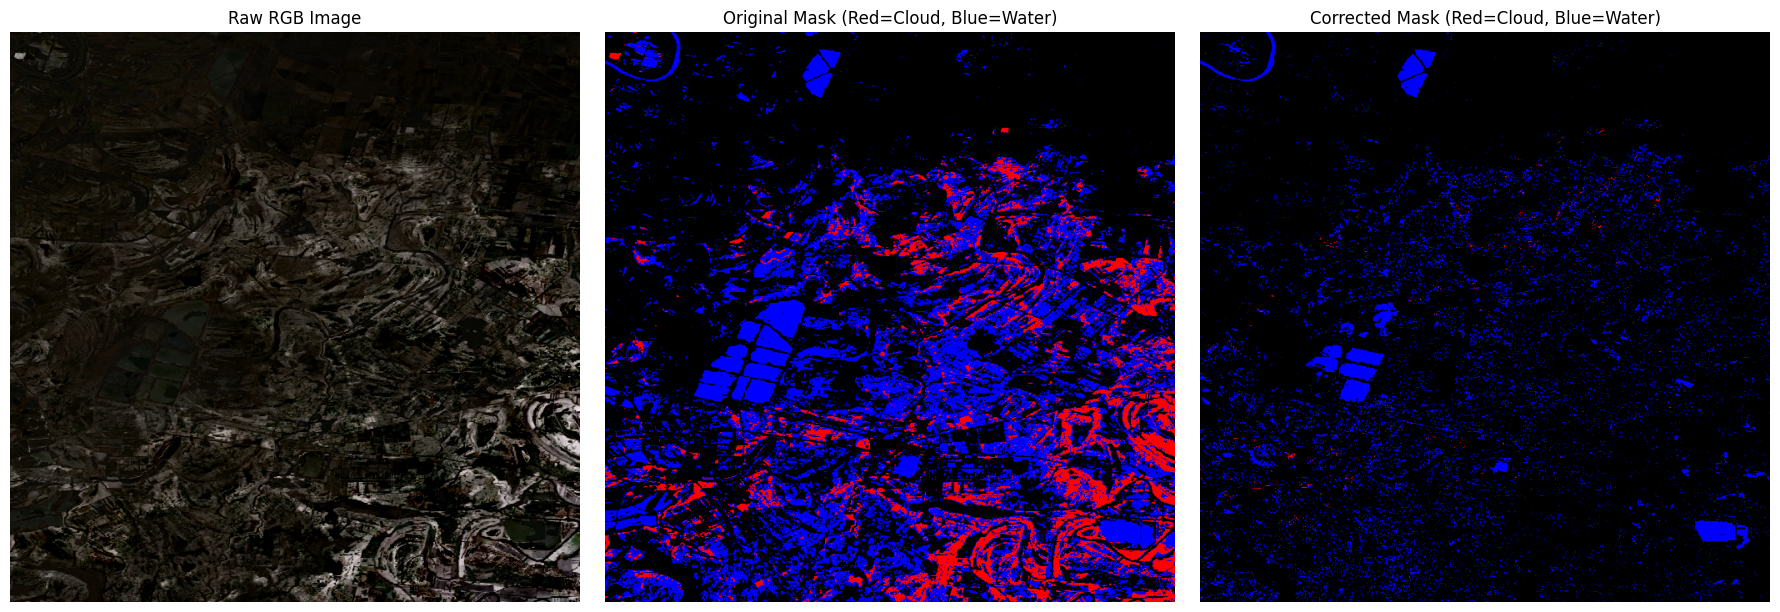

In [ ]:
correct_mask_ndsi_ndwi(
    raw_image_path="/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/response.tiff",
    mask_path="/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/response.tiff",
    output_path="/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2//waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/response.tiff"
)


Workflow for inspecting and changing the mask because of ice/snow

In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from geopy.geocoders import Nominatim
import requests
import sys
from IPython.display import display, HTML


def get_coords_from_tiff(tiff_path):
    with rasterio.open(tiff_path) as src:
        bounds = src.bounds
        center_lon = (bounds.left + bounds.right) / 2
        center_lat = (bounds.top + bounds.bottom) / 2
    return center_lat, center_lon

# def get_region_from_coords(lat, lon):
#     geolocator = Nominatim(user_agent="landsat_inspector")
#     try:
#         location = geolocator.reverse((lat, lon), language='en')
#         return location.raw.get('address', {}).get('state', 'Unknown region')
#     except:
#         return "Unknown region"

def get_max_elevation(lat, lon, delta=0.01):
    url = f"https://api.opentopodata.org/v1/aster30m?locations={lat+delta},{lon+delta}|{lat-delta},{lon-delta}"
    try:
        resp = requests.get(url)
        data = resp.json()
        elevations = [res["elevation"] for res in data["results"] if res["elevation"] is not None]
        return max(elevations) if elevations else "Unknown"
    except:
        return "Unknown"

def visualize_raw_and_mask(raw_path, mask_path, width = "1200px"):
    with rasterio.open(raw_path) as raw_src:
        rgb = raw_src.read([3, 2, 1])
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = np.clip(rgb / np.max(rgb), 0, 1)

    with rasterio.open(mask_path) as mask_src:
        mask = mask_src.read()
        mask = np.transpose(mask, (1, 2, 0))

    fig, axs = plt.subplots(2,1, figsize=(6, 12))
    axs[0].imshow(rgb)
    axs[0].set_title("Raw Image")
    axs[0].axis('off')
    axs[1].imshow(mask)
    axs[1].set_title("Original Mask")
    axs[1].axis('off')
    plt.tight_layout()

    display(HTML(f"<div>"))
    plt.show()
    display(HTML("</div>"))





def manual_review_landsat(base_dir):
    for mask_folder in glob(os.path.join(base_dir, '*_masks')):
        raw_folder = mask_folder.replace('_masks', '_raw')

        for subfolder in os.listdir(mask_folder):
            mask_sub = os.path.join(mask_folder, subfolder)
            raw_sub = os.path.join(raw_folder, subfolder)

            if not os.path.isdir(mask_sub):
                continue

            try:
                mask_random = glob(os.path.join(mask_sub, '*', 'response.tiff'))[0]
                raw_random = glob(os.path.join(raw_sub, '*', 'response.tiff'))[0]
            except IndexError:
                continue

            lat, lon = get_coords_from_tiff(raw_random)

            bounds = get_image_bbox(raw_random)

            center_lat = (bounds.top + bounds.bottom) / 2
            center_lon = (bounds.left + bounds.right) / 2
            region = reverse_geocode(center_lat, center_lon)

            #region = get_region_from_coords(lat, lon)
            elevation = get_max_elevation(lat, lon)

            visualize_raw_and_mask(raw_random, mask_random)


            print(f"\nCoordinates: ({lat:.4f}, {lon:.4f})")
            print(f"Region: {region}")
            print(f"Max elevation: {elevation} m")
            print(f"Mask: {mask_random}")
            print(f"Raw: {raw_random}")



            user_input = input_func(raw_random, mask_random)


# Usage:
# manual_review_landsat("/path/to/LANDSAT_OT_L2")


In [ ]:
def input_func(raw_random, mask_random):
  user_input = input("Press [Enter] to skip or type 'c' to correct ice/snow: ")
  if user_input.strip().lower() == 'c':
      correct_mask_ndsi_ndwi(raw_random, mask_random, mask_random)
      print("✅ Mask corrected and saved.")
      visualize_raw_and_mask(raw_random, mask_random)
  else:
      print("⏩ Skipped.")

In [ ]:
manual_review_landsat("/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2")

### Mask correction using the water body map

In [ ]:
# Install Earth Engine and authenticate
!pip install earthengine-api --quiet
import ee
ee.Authenticate()


In [ ]:
ee.Initialize(project="ds-project-460918")


In [ ]:

def shapely_to_ee_geometry(shapely_geom):
    coords = list(shapely_geom.exterior.coords)
    return ee.Geometry.Polygon([coords])


In [ ]:
ee_geometry = shapely_to_ee_geometry(AOI_Polygon)


In [ ]:
def get_bbox(path):
    with rasterio.open(path) as src:
        bounds = src.bounds
        crs = src.crs
    return bounds, crs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import rasterio
import numpy as np
from glob import glob
from rasterio.enums import Resampling
from rasterio.warp import reproject
import ee


In [ ]:

# ---------- EARTH ENGINE EXPORT SETUP ----------

def get_bbox_from_tiff(tiff_path):
    with rasterio.open(tiff_path) as src:
        bounds = src.bounds
    return bounds  # minx, miny, maxx, maxy

def export_jrc_patch(minx, miny, maxx, maxy, file_name, project_id='ds-project-460918'):
    ee.Initialize(project=project_id)

    aoi = ee.Geometry.BBox(minx, miny, maxx, maxy)
    jrc = ee.Image("JRC/GSW1_3/GlobalSurfaceWater")
    water = jrc.select('occurrence').gte(50).clip(aoi)

    task = ee.batch.Export.image.toDrive(
        image=water,
        description=file_name,
        folder='GEE_JRC_EXPORTS',
        fileNamePrefix=file_name,
        region=aoi,
        scale=30,
        crs='EPSG:4326',
        maxPixels=1e8
    )

    task.start()
    print(f"✅ Export started for {file_name}")

def batch_export_jrc_from_masks(mask_root_folder, project_id='ds-project-460918'):
    # Go two levels deep: informative folder → random subfolder → response.tiff
    search_pattern = os.path.join(mask_root_folder, 'data_Q*_202*_masks', '*', '*', 'response.tiff')
    mask_paths = glob(search_pattern)

    for mask_path in mask_paths:
        try:
            # Example path:
            # .../data_Q3_2023_masks/Q3_2023_01_1234/a9d0f3210f/response.tiff

            random_folder = os.path.dirname(mask_path)
            informative_folder = os.path.basename(os.path.dirname(random_folder))
            parent_folder = os.path.basename(os.path.dirname(os.path.dirname(random_folder)))  # e.g., data_Q3_2023_masks
            quarter_year = parent_folder.replace('data_', '').replace('_masks', '')  # Q3_2023

            file_name = f"{quarter_year}_{informative_folder}"

            # Get bounding box and export
            minx, miny, maxx, maxy = get_bbox_from_tiff(mask_path)
            export_jrc_patch(minx, miny, maxx, maxy, file_name=file_name, project_id=project_id)

        except Exception as e:
            print(f"❌ Failed to export JRC for {mask_path}: {e}")


In [ ]:
batch_export_jrc_from_masks(
    mask_root_folder='/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2',
    project_id='ds-project-460918'
)

/usr/local/lib/python3.11/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for JRC/GSW1_3/GlobalSurfaceWater! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/JRC_GSW1_3_GlobalSurfaceWater

  warnings.warn(warning, category=DeprecationWarning)


✅ Export started for Q1_2023_Q1_2023_00_3615
✅ Export started for Q1_2023_Q1_2023_01_4527
✅ Export started for Q1_2023_Q1_2023_02_6820
✅ Export started for Q1_2023_Q1_2023_03_9348
✅ Export started for Q1_2023_Q1_2023_04_9669
✅ Export started for Q1_2023_Q1_2023_05_6573
✅ Export started for Q1_2023_Q1_2023_06_9727
✅ Export started for Q1_2023_Q1_2023_07_3705
✅ Export started for Q1_2023_Q1_2023_08_5061
✅ Export started for Q1_2023_Q1_2023_09_7939
✅ Export started for Q1_2023_Q1_2023_10_2612
✅ Export started for Q1_2023_Q1_2023_11_5073
✅ Export started for Q1_2023_Q1_2023_12_7912
✅ Export started for Q1_2023_Q1_2023_13_2528
✅ Export started for Q1_2023_Q1_2023_14_7570
✅ Export started for Q1_2023_Q1_2023_15_5673
✅ Export started for Q1_2023_Q1_2023_16_4044
✅ Export started for Q1_2023_Q1_2023_17_8491
✅ Export started for Q1_2023_Q1_2023_18_1152
✅ Export started for Q1_2023_Q1_2023_19_2753
✅ Export started for Q1_2023_Q1_2023_20_5325
✅ Export started for Q1_2023_Q1_2023_21_2512
✅ Export s

In [ ]:
import os
from glob import glob

def batch_export_jrc_from_custom_masks(mask_root_folder, project_id='ds-project-460918'):
    # List only folders that are NOT the standard quarterly ones (i.e., not starting with 'data_Q')
    for entry in os.listdir(mask_root_folder):
        if not entry.startswith("data_Q") and entry.endswith("_masks"):
            folder_path = os.path.join(mask_root_folder, entry)
            if not os.path.isdir(folder_path):
                continue

            # Go two levels deep: informative folder → random subfolder → response.tiff
            search_pattern = os.path.join(folder_path, '*', '*', 'response.tiff')
            mask_paths = glob(search_pattern)

            for mask_path in mask_paths:
                try:
                    # e.g., .../data_boris24_2024_masks/boris24_00_xxxx/randomid/response.tiff
                    random_folder = os.path.dirname(mask_path)
                    informative_folder = os.path.basename(os.path.dirname(random_folder))
                    dataset_folder = os.path.basename(os.path.dirname(os.path.dirname(random_folder)))

                    file_name = f"{dataset_folder.replace('_masks', '')}_{informative_folder}"

                    # Get bounding box and export
                    minx, miny, maxx, maxy = get_bbox_from_tiff(mask_path)
                    export_jrc_patch(minx, miny, maxx, maxy, file_name=file_name, project_id=project_id)

                except Exception as e:
                    print(f"❌ Failed to export JRC for {mask_path}: {e}")


In [ ]:
batch_export_jrc_from_custom_masks(
    mask_root_folder='/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2',
    project_id='ds-project-460918'
)

/usr/local/lib/python3.11/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for JRC/GSW1_3/GlobalSurfaceWater! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/JRC_GSW1_3_GlobalSurfaceWater

  warnings.warn(warning, category=DeprecationWarning)


✅ Export started for data_germany21_2021_germany21_00_1869
✅ Export started for data_germany21_2021_germany21_01_4269
✅ Export started for data_germany21_2021_germany21_02_9628
✅ Export started for data_germany21_2021_germany21_03_8595
✅ Export started for data_germany21_2021_germany21_04_1080
✅ Export started for data_germany21_2021_germany21_05_4192
✅ Export started for data_germany21_2021_germany21_06_7573
✅ Export started for data_germany21_2021_germany21_07_1879
✅ Export started for data_germany21_2021_germany21_08_7506
✅ Export started for data_germany21_2021_germany21_09_2768
✅ Export started for waterbodies_data_Q1_2022_Q1_2022_00_2485
✅ Export started for waterbodies_data_Q1_2022_Q1_2022_01_1572
✅ Export started for waterbodies_data_Q1_2022_Q1_2022_02_6810
✅ Export started for waterbodies_data_Q1_2022_Q1_2022_03_1259
✅ Export started for waterbodies_data_Q1_2022_Q1_2022_04_1239
✅ Export started for waterbodies_data_Q1_2022_Q1_2022_05_2057
✅ Export started for waterbodies_data_

In [ ]:
# ---------- LOCAL CORRECTION SETUP ----------

def correct_mask_with_jrc_local(mask_path, jrc_patch_path, output_path):
    with rasterio.open(mask_path) as mask_src, rasterio.open(jrc_patch_path) as jrc_src:
        # Read 3-band RGB-style mask
        bands = mask_src.read()
        cloud_band = bands[0]
        water_band = bands[2]  # band 3

        cloud_mask = (cloud_band == 255)
        water_mask = (water_band == 255)


        # Reconstruct single-band mask: 2 = cloud, 1 = water, 0 = background
        mask = np.zeros_like(cloud_band, dtype=np.uint8)
        mask[cloud_mask] = 2
        mask[~cloud_mask & water_mask] = 1

        # Prepare for correction
        profile = mask_src.profile
        profile.update(count=1, dtype=np.uint8)
        transform = mask_src.transform
        crs = mask_src.crs
        shape_ = mask.shape

        # Read and resample JRC patch
        jrc_data = jrc_src.read(1)
        jrc_resampled = np.zeros(shape_, dtype=np.uint8)

        reproject(
            source=jrc_data,
            destination=jrc_resampled,
            src_transform=jrc_src.transform,
            src_crs=jrc_src.crs,
            dst_transform=transform,
            dst_crs=crs,
            resampling=Resampling.nearest
        )

        # Apply correction: add water only where mask == 0 (other)
        corrected = mask.copy()
        added_water = (mask == 0) & (jrc_resampled == 1)
        corrected[added_water] = 1

        print(f"✅ Water pixels added: {np.sum(added_water)}")

        # Save corrected mask
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(corrected, 1)

        print(f"✅ Corrected mask saved to: {output_path}")


def batch_correct_masks_with_local_jrc(mask_root_folder, jrc_patch_folder):
    # Match nested response.tiff
    mask_paths = glob(os.path.join(mask_root_folder, 'data_Q*_202*_masks', '*', '*', 'response.tiff'))

    for mask_path in mask_paths:
        random_folder = os.path.dirname(mask_path)
        informative_folder = os.path.basename(os.path.dirname(random_folder))
        parent_folder = os.path.basename(os.path.dirname(os.path.dirname(random_folder)))  # e.g., data_Q3_2023_masks
        quarter_year = parent_folder.replace('data_', '').replace('_masks', '')

        jrc_file_name = f"{quarter_year}_{informative_folder}.tif"
        jrc_path = os.path.join(jrc_patch_folder, jrc_file_name)
        output_path = os.path.join(random_folder, "corrected_response.tiff")

        if not os.path.exists(jrc_path):
            print(f"⚠️ Skipping {jrc_file_name} — JRC patch not found.")
            continue

        try:
            correct_mask_with_jrc_local(mask_path, jrc_path, output_path)
        except Exception as e:
            print(f"❌ Failed to correct {informative_folder}: {e}")


In [ ]:
batch_correct_masks_with_local_jrc(
    mask_root_folder='/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2',
    jrc_patch_folder='/content/drive/My Drive/GEE_JRC_EXPORTS'
)


✅ Water pixels added: 417
✅ Corrected mask saved to: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q1_2023_masks/Q1_2023_00_3615/7f67068903a36f971a3e207a83532401/corrected_response.tiff
✅ Water pixels added: 117
✅ Corrected mask saved to: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q1_2023_masks/Q1_2023_01_4527/407835f66b2601e6c79b022a1415e31c/corrected_response.tiff
✅ Water pixels added: 4160
✅ Corrected mask saved to: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q1_2023_masks/Q1_2023_02_6820/fe47681dae1fa4ff2c190a73ad55ef21/corrected_response.tiff
✅ Water pixels added: 1969
✅ Corrected mask saved to: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q1_2023_masks/Q1_2023_03_9348/48f1ca19e825b1a9676828d522d92c03/corrected_response.tiff
✅ Water pixels added: 698
✅ Corrected mask saved to: /content/drive/My Drive/01 Da

In [ ]:
def batch_correct_masks_with_local_jrc_waterbodies(mask_root_folder, jrc_patch_folder):
    # Match nested response.tiff
    mask_paths = glob(os.path.join(mask_root_folder, 'data_Q*_202*_masks', '*', '*', 'response.tiff'))

    for mask_path in mask_paths:
        random_folder = os.path.dirname(mask_path)
        informative_folder = os.path.basename(os.path.dirname(random_folder))
        parent_folder = os.path.basename(os.path.dirname(os.path.dirname(random_folder)))  # e.g., data_Q3_2023_masks
        quarter_year = parent_folder.replace('data_', '').replace('_masks', '')

        jrc_file_name = f"{quarter_year}_{informative_folder}.tif"
        jrc_path = os.path.join(jrc_patch_folder, jrc_file_name)
        output_path = os.path.join(random_folder, "corrected_response.tiff")

        if not os.path.exists(jrc_path):
            print(f"⚠️ Skipping {jrc_file_name} — JRC patch not found.")
            continue

        try:
            correct_mask_with_jrc_local(mask_path, jrc_path, output_path)
        except Exception as e:
            print(f"❌ Failed to correct {informative_folder}: {e}")

Original mask class counts:
Class 0: 435208 pixels
Class 1: 32167 pixels
Class 2: 481 pixels
[0 1 2]


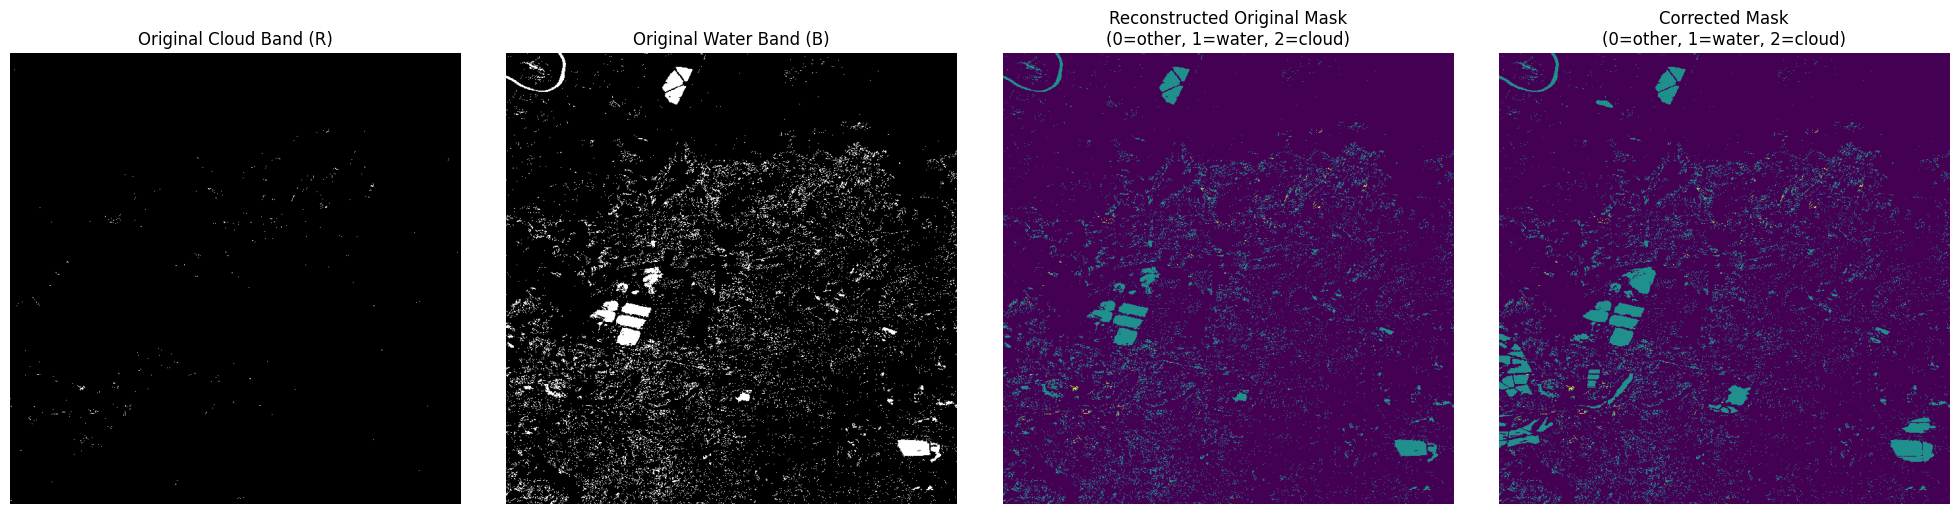

In [ ]:
# debugging the correction
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Paths to one example mask and corrected mask — replace with actual paths in your environment
example_original_mask_path = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/response.tiff"
example_corrected_mask_path = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/corrected_response.tiff"

# Load the original 3-band RGB-style mask
with rasterio.open(example_original_mask_path) as src:
    bands = src.read()
    profile = src.profile

# Extract cloud and water bands
cloud_band = bands[0]
water_band = bands[2]

cloud_mask = (cloud_band == 255)  # might still be all zeros
water_mask = (water_band == 255)


# Reconstruct single-band mask: 2 = cloud, 1 = water, 0 = background
original_mask = np.zeros_like(cloud_band, dtype=np.uint8)
original_mask[cloud_mask] = 2
original_mask[~cloud_mask & water_mask] = 1

unique, counts = np.unique(original_mask, return_counts=True)
print("Original mask class counts:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} pixels")


# Load the corrected mask
with rasterio.open(example_corrected_mask_path) as src:
    corrected_mask = src.read(1)

# Calculate difference
diff = corrected_mask.astype(int) - original_mask.astype(int)

print(np.unique(corrected_mask))

# Prepare plots
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(cloud_band, cmap='gray')
axs[0].set_title("Original Cloud Band (R)")
axs[0].axis('off')

axs[1].imshow(water_band, cmap='gray')
axs[1].set_title("Original Water Band (B)")
axs[1].axis('off')

axs[2].imshow(original_mask, cmap='viridis', vmin=0, vmax=2)
axs[2].set_title("Reconstructed Original Mask\n(0=other, 1=water, 2=cloud)")
axs[2].axis('off')

axs[3].imshow(corrected_mask, cmap='viridis', vmin=0, vmax=2)
axs[3].set_title("Corrected Mask\n(0=other, 1=water, 2=cloud)")
axs[3].axis('off')

plt.tight_layout()
plt.show()



In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_image_comparison(raw_image_path, mask_path, corrected_mask_path):

     # Read raw image
    with rasterio.open(raw_image_path) as raw_src:
        rgb = raw_src.read([3, 2, 1])  # RGB (B04, B03, B02)
        rgb = np.transpose(rgb, (1, 2, 0))  # (H, W, C)
        rgb = rgb.astype(np.float32)
        rgb /= rgb.max()  # Normalize to 0-1


    # Load original mask
    with rasterio.open(mask_path) as mask_src:
        original_mask = mask_src.read()
        original_mask = np.transpose(original_mask, (1, 2, 0))  # (H, W, C)

  # load corrected mask
    with rasterio.open(corrected_mask_path) as mask_src_corrected:
      corrected_mask = mask_src_corrected.read()
      corrected_mask = np.transpose(corrected_mask, (1, 2, 0))  # (H, W, C)



    # Plot
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(rgb)
    axs[0].set_title("Raw RGB Image")
    axs[0].axis('off')

    axs[1].imshow(original_mask, cmap='Blues')
    axs[1].set_title("Original Mask")
    axs[1].axis('off')

    axs[2].imshow(corrected_mask, cmap='viridis', vmin=0, vmax=2)
    axs[2].set_title("Corrected Mask\n(0=other, 1=water, 2=cloud)")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

raw_folder = '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q1_2022_raw'
mask_folder = '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q1_2022_masks'

# Get list of all informative subfolders
raw_subfolders = sorted(os.listdir(raw_folder))
mask_subfolders = sorted(os.listdir(mask_folder))

# Loop through matching folders
for raw_info, mask_info in zip(raw_subfolders, mask_subfolders):
    raw_info_path = os.path.join(raw_folder, raw_info)
    mask_info_path = os.path.join(mask_folder, mask_info)

    # Expecting one subfolder (random ID) inside each informative folder
    raw_inner = os.listdir(raw_info_path)
    mask_inner = os.listdir(mask_info_path)

    if not raw_inner or not mask_inner:
        print(f"⚠️ Skipping {raw_info} due to missing inner folders.")
        continue

    raw_tiff_path = os.path.join(raw_info_path, raw_inner[0], 'response.tiff')
    mask_tiff_path = os.path.join(mask_info_path, mask_inner[0], 'response.tiff')
    corrected_mask_path = os.path.join(mask_info_path, mask_inner[0], 'corrected_response.tiff')

    if not all(os.path.exists(p) for p in [raw_tiff_path, mask_tiff_path, corrected_mask_path]):
        print(f"⚠️ Missing file for: {raw_info}")
        continue

    print(f"✅ All files found for: {raw_info}")

    # Read raw image (RGB)
    with rasterio.open(raw_tiff_path) as raw_src:
        raw_img = raw_src.read([3, 2, 1])
        raw_img = np.transpose(raw_img, (1, 2, 0))
        raw_img = raw_img.astype(np.float32)
        raw_img /= raw_img.max()

    # Read mask
    with rasterio.open(mask_tiff_path) as mask_src:
        mask_bands = mask_src.read()
        cloud_mask = mask_bands[0] == 255
        water_mask = mask_bands[2] == 255
        reconstructed_mask = np.zeros_like(cloud_mask, dtype=np.uint8)
        reconstructed_mask[cloud_mask] = 2
        reconstructed_mask[~cloud_mask & water_mask] = 1

    # Read corrected mask
    with rasterio.open(corrected_mask_path) as corrected_src:
        corrected_mask = corrected_src.read(1)

    # Plot side by side
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    axs[0].imshow(raw_img)
    axs[0].set_title(f"Raw Image")
    axs[0].axis('off')

    axs[1].imshow(reconstructed_mask, cmap='viridis', vmin=0, vmax=2)
    axs[1].set_title("Original Mask (decoded)")
    axs[1].axis('off')

    axs[2].imshow(corrected_mask, cmap='viridis', vmin=0, vmax=2)
    axs[2].set_title("Corrected Mask")
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()


In [48]:
image_path = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/response.tiff"
mask_path = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/corrected_response.tiff"

In [7]:
def get_image_info(path):
    try:
        with rasterio.open(path) as src:
            print(f"📄 File: {path}")
            print(f"🖼️ Dimensions: {src.width} x {src.height} (W x H)")
            print(f"📊 Number of Bands: {src.count}")
            print(f"📏 Data Types: {[src.dtypes[i] for i in range(src.count)]}")
            print(f"📐 Resolution: {src.res[0]} x {src.res[1]} (units: {src.crs.to_string()})")
            print(f"🌍 CRS: {src.crs}")

        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"💾 File Size: {size_mb:.2f} MB")

    except Exception as e:
        print(f"❌ Error reading {path}: {e}")


In [34]:
get_image_info(image_path)
get_image_info(mask_path)

📄 File: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/response.tiff
🖼️ Dimensions: 684 x 684 (W x H)
📊 Number of Bands: 4
📏 Data Types: ['uint8', 'uint8', 'uint8', 'uint8']
📐 Resolution: 0.000438596491228066 x 0.000438596491228066 (units: EPSG:4326)
🌍 CRS: EPSG:4326
💾 File Size: 1.32 MB
📄 File: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/corrected_response.tiff
🖼️ Dimensions: 684 x 684 (W x H)
📊 Number of Bands: 1
📏 Data Types: ['uint8']
📐 Resolution: 0.000438596491228066 x 0.000438596491228066 (units: EPSG:4326)
🌍 CRS: EPSG:4326
💾 File Size: 0.03 MB


In [ ]:
import numpy as np
import rasterio

def inspect_mask_values(mask_path):
    with rasterio.open(mask_path) as src:
        data = src.read(1)
        unique, counts = np.unique(data, return_counts=True)
        for val, count in zip(unique, counts):
            print(f"Value {val}: {count} pixels")


In [ ]:
with rasterio.open("/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_03_6525/c720db5621f6f6c6f9e77fc94f939b35/test.tiff") as src:
    print("CRS:", src.crs)
    print("Shape:", src.shape)
    print("Count (bands):", src.count)
    print("Description:", src.descriptions)


CRS: EPSG:4326
Shape: (684, 684)
Count (bands): 4
Description: (None, None, None, None)


In [ ]:
inspect_mask_values("/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q3_2023_masks/bcff54c57f3e17d6968398b019635d31/response.tiff")


Value 0: 4194304 pixels


Original dtype: uint8


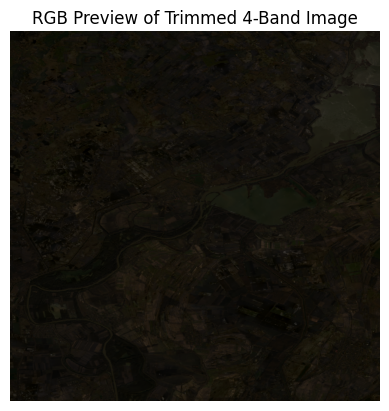

✅ Saved: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_03_6525/c720db5621f6f6c6f9e77fc94f939b35/test.tiff


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_03_6525/c720db5621f6f6c6f9e77fc94f939b35/response.tiff"
output_path = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_03_6525/c720db5621f6f6c6f9e77fc94f939b35/test.tiff"

# Open the original image
with rasterio.open(image_path) as src:
    # Correct Landsat 8 bands: B04 (Red), B03 (Green), B02 (Blue), B05 (NIR)
    selected_bands = [3, 2, 1, 4]  # R, G, B, NIR
    data = src.read(selected_bands)  # shape (4, H, W)

    # Confirm dtype
    print("Original dtype:", data.dtype)

    # Convert to uint8 if needed
    if data.dtype != np.uint8:
        print("Converting to uint8...")
        data = np.clip(data, 0, 255)
        data = data.astype(np.uint8)

    # Prepare new profile
    profile = src.profile
    profile.update(count=4, dtype='uint8')

    # Save the 4-band image
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(data)

# ✅ Visual check
rgb = np.transpose(data[:3], (1, 2, 0))  # Only RGB
rgb = rgb.astype(np.float32) / 255.0  # Normalize for visualization

plt.imshow(np.clip(rgb, 0, 1))
plt.title("RGB Preview of Trimmed 4-Band Image")
plt.axis("off")
plt.show()

print("✅ Saved:", output_path)


In [ ]:
import os
import rasterio
from glob import glob

def delete_bands_keep_rgb_nir(base_dir):
    raw_dirs = glob(os.path.join(base_dir, "*_raw"))

    for raw_dir in raw_dirs:
        for subfolder in os.listdir(raw_dir):
            subfolder_path = os.path.join(raw_dir, subfolder)
            if not os.path.isdir(subfolder_path):
                continue

            try:
                # Find the response.tiff file in the nested folder
                tiff_path = glob(os.path.join(subfolder_path, '*', 'response.tiff'))[0]
                with rasterio.open(tiff_path) as src:
                    # Select bands: B04 (R), B03 (G), B02 (B), B05 (NIR)
                    selected_bands = [3, 2, 1, 4]
                    data = src.read(selected_bands).astype('uint8')  # Optional: ensure uniform dtype
                    profile = src.profile
                    profile.update(count=4, dtype='uint8')

                # Overwrite the same file
                with rasterio.open(tiff_path, 'w', **profile) as dst:
                    dst.write(data)

                print(f"✅ Updated: {tiff_path}")

            except Exception as e:
                print(f"❌ Failed to process {subfolder_path}: {e}")

# Example usage
delete_bands_keep_rgb_nir("/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2")


### Transforming the landsat resolution from 30m to 10m

In [13]:
!apt-get update --fix-missing

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,721 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,734 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,991 kB]
Get:13 http://archive.ubuntu.com/ubuntu jamm

In [14]:
!apt-get install -y gdal-bin


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-gdal python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 36 not upgraded.
Need to get 5,168 kB of archives.
After this operation, 25.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.8.4+dfsg-1~jammy0 [605 kB]
Fetched 5,168 kB in 1s (3,760 kB/s)
Selecting previously unselected package python3-numpy.
(Reading database ... 126109 files and direc

In [35]:
import subprocess

output_path  = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/upscaled_response.tiff"
cropped_path = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/cropped_response.tiff"

from rasterio.windows import Window
from rasterio.transform import Affine
import os


# Crop to center 228×228 region
with rasterio.open(image_path) as src:
    width, height = src.width, src.height
    crop_size = 228
    left = (width - crop_size) // 2
    top = (height - crop_size) // 2

    window = Window(left, top, crop_size, crop_size)
    transform = src.window_transform(window)
    profile = src.profile
    profile.update({
        "height": crop_size,
        "width": crop_size,
        "transform": transform
    })

    data = src.read(window=window)

# Save cropped
with rasterio.open(cropped_path, 'w', **profile) as dst:
    dst.write(data)

# Upsample with GDAL to 2048×2048 using 10m equivalent resolution
resolution = 4.8828125e-05  # ~10m in EPSG:4326
cmd = [
    "gdalwarp",
    "-tr", str(resolution), str(resolution),
    "-r", "bilinear",
    "-co", "COMPRESS=LZW",
    "-co", "TILED=YES",
    cropped_path,
    output_path
]
subprocess.run(cmd, check=True)



CompletedProcess(args=['gdalwarp', '-tr', '4.8828125e-05', '4.8828125e-05', '-r', 'bilinear', '-co', 'COMPRESS=LZW', '-co', 'TILED=YES', '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/cropped_response.tiff', '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/upscaled_response.tiff'], returncode=0)

In [36]:
get_image_info(output_path)

📄 File: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/upscaled_response.tiff
🖼️ Dimensions: 2048 x 2048 (W x H)
📊 Number of Bands: 4
📏 Data Types: ['uint8', 'uint8', 'uint8', 'uint8']
📐 Resolution: 4.8828125e-05 x 4.8828125e-05 (units: EPSG:4326)
🌍 CRS: EPSG:4326
💾 File Size: 10.25 MB


In [37]:
crop_size = 228
mask_cropped = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/corrected_response_cropped.tiff"
mask_output = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/corrected_response_upscaled.tiff"

with rasterio.open(mask_path) as mask_src:
    width, height = mask_src.width, mask_src.height
    left = (width - crop_size) // 2
    top = (height - crop_size) // 2
    window = Window(left, top, crop_size, crop_size)

    mask_data = mask_src.read(window=window)
    mask_transform = mask_src.window_transform(window)
    mask_profile = mask_src.profile.copy()
    mask_profile.update({
        "height": crop_size,
        "width": crop_size,
        "transform": mask_transform
    })

    with rasterio.open(mask_cropped, "w", **mask_profile) as dst:
        dst.write(mask_data)

subprocess.run([
    "gdalwarp",
    "-tr", str(resolution), str(resolution),
    "-r", "near",
    "-co", "COMPRESS=LZW",
    "-co", "TILED=YES",
    mask_cropped,
    mask_output
], check=True)

CompletedProcess(args=['gdalwarp', '-tr', '4.8828125e-05', '4.8828125e-05', '-r', 'near', '-co', 'COMPRESS=LZW', '-co', 'TILED=YES', '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/corrected_response_cropped.tiff', '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/corrected_response_upscaled.tiff'], returncode=0)

In [38]:
get_image_info(mask_output)

📄 File: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_masks/Q1_2024_02_8141/d49bf7735512b051d0d803fb66c259a8/corrected_response_upscaled.tiff
🖼️ Dimensions: 2048 x 2048 (W x H)
📊 Number of Bands: 1
📏 Data Types: ['uint8']
📐 Resolution: 4.8828125e-05 x 4.8828125e-05 (units: EPSG:4326)
🌍 CRS: EPSG:4326
💾 File Size: 0.09 MB


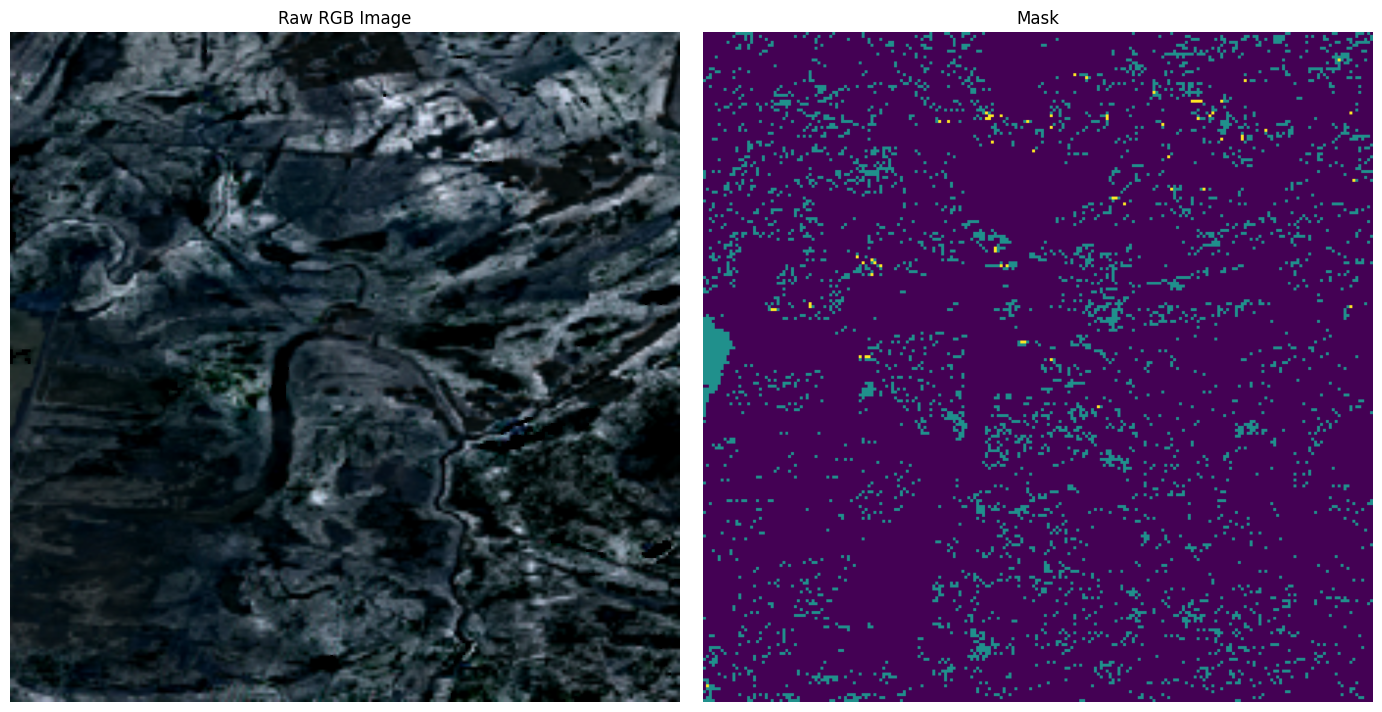

In [56]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def visualize_raw_and_mask(raw_path, mask_path):
    # Load raw image (assuming bands R=4, G=3, B=2)
    with rasterio.open(raw_path) as src:
        raw_rgb = src.read([3, 2, 1])  # Bands are 1-based: R, G, B
        raw_rgb = np.transpose(raw_rgb, (1, 2, 0)).astype(np.float32)
        raw_rgb /= raw_rgb.max()  # Normalize to [0, 1]

    # Load mask
    with rasterio.open(mask_path) as src:
        mask = src.read()
        mask = np.transpose(mask, (1, 2, 0))

    # Plot side by side
    fig, axs = plt.subplots(1, 2, figsize=(14, 7))
    axs[0].imshow(raw_rgb)
    axs[0].set_title("Raw RGB Image")
    axs[0].axis("off")

    axs[1].imshow(mask)
    axs[1].set_title("Mask")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

visualize_raw_and_mask(output_path, mask_output)


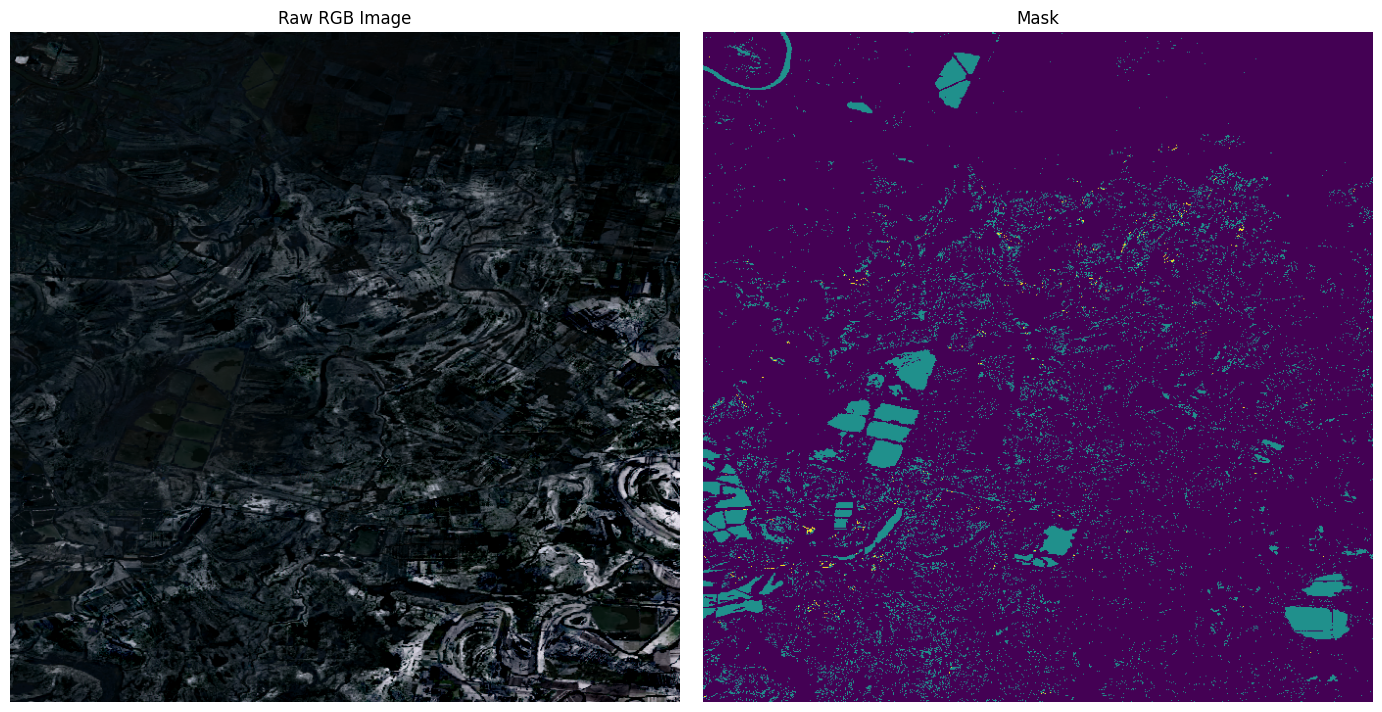

In [55]:
visualize_raw_and_mask(image_path, mask_path)

In [53]:
import os
import rasterio
from rasterio.windows import Window
import subprocess

def crop_and_resample(input_path, output_path, crop_size=228, target_resolution=4.8828125e-05, resampling="bilinear"):
    """
    Crop the center 228x228 of the image and upsample to 2048x2048 using GDAL.
    """
    cropped_tmp = input_path.replace(".tiff", "_cropped_temp.tiff")

    # Step 1: Crop to center
    with rasterio.open(input_path) as src:
        width, height = src.width, src.height
        left = (width - crop_size) // 2
        top = (height - crop_size) // 2
        window = Window(left, top, crop_size, crop_size)
        transform = src.window_transform(window)
        profile = src.profile
        profile.update({
            "height": crop_size,
            "width": crop_size,
            "transform": transform,
            "count": src.count
        })
        data = src.read(window=window)

    with rasterio.open(cropped_tmp, 'w', **profile) as dst:
        dst.write(data)

    # Step 2: Resample with GDAL
    cmd = [
        "gdalwarp",
        "-tr", str(target_resolution), str(target_resolution),
        "-r", resampling,
        "-co", "COMPRESS=LZW",
        "-co", "TILED=YES",
        "-co", "BLOCKXSIZE=256",
        "-co", "BLOCKYSIZE=256",
        cropped_tmp,
        output_path
    ]
    subprocess.run(cmd, check=True)

    # Clean up cropped temp file
    os.remove(cropped_tmp)


In [59]:
crop_and_resample(image_path, output_path)

In [54]:
crop_and_resample(mask_path, mask_output, resampling="near")

In [60]:
get_image_info(output_path)

📄 File: /content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/waterbodies_data_Q1_2024_raw/Q1_2024_02_8141/adeb06a37b0571c489326adc3c188b24/upscaled_response.tiff
🖼️ Dimensions: 2048 x 2048 (W x H)
📊 Number of Bands: 4
📏 Data Types: ['uint8', 'uint8', 'uint8', 'uint8']
📐 Resolution: 4.8828125e-05 x 4.8828125e-05 (units: EPSG:4326)
🌍 CRS: EPSG:4326
💾 File Size: 10.25 MB


In [80]:
import os
import subprocess
import glob

# Root directory where all raw/mask folders are stored
base_dir = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2"

# Set resolution (approx. 10m in degrees for EPSG:4326)
resolution = 4.8828125e-05

# Loop through Q1–Q4 folders across 2022–2024
for year in range(0,1):
    for quarter in ["Q1", "Q2", "Q3", "Q4"]:
        for suffix in ["raw", "masks"]:
            folder_name = f"data_germany21_2021_{suffix}"
            full_folder_path = os.path.join(base_dir, folder_name)

            if not os.path.exists(full_folder_path):
                print(f"Skipping missing folder: {folder_name}")
                continue

            print(f"📂 Processing: {folder_name}")

            # Iterate over all informative folders
            for informative_folder in os.listdir(full_folder_path):
                informative_path = os.path.join(full_folder_path, informative_folder)
                if not os.path.isdir(informative_path):
                    continue

                # Expect one subfolder with random name
                subfolders = os.listdir(informative_path)
                if not subfolders:
                    print(f"⚠️ No inner folder in: {informative_path}")
                    continue

                random_id_folder = os.path.join(informative_path, subfolders[0])
                # Use corrected mask for transformation if in "masks" folder
                input_filename = "corrected_response.tiff" if suffix == "masks" else "response.tiff"
                input_tiff = os.path.join(random_id_folder, input_filename)

                                # Create a local output folder if it doesn't exist
                local_output_dir = f"/content/transformed_LANDSAT_germany21/{folder_name}/{informative_folder}"
                os.makedirs(local_output_dir, exist_ok=True)

                # Save with informative name (e.g., Q1_2023_00_1234.tiff)
                output_tiff = os.path.join(local_output_dir, f"{input_filename.replace('.tiff', '')}_transformed.tiff")


                if not os.path.exists(input_tiff):
                    print(f"⚠️ Missing input TIFF: {input_tiff}")
                    continue

                resampling = "bilinear" if suffix == "raw" else "near"

                try:
                    crop_and_resample(input_tiff, output_tiff, resampling=resampling)
                    print(f"✅ Processed: {output_tiff}")
                except Exception as e:
                    print(f"❌ Failed for {input_tiff}: {e}")



📂 Processing: data_germany21_2021_raw
✅ Processed: /content/transformed_LANDSAT_germany21/data_germany21_2021_raw/germany21_00_1869/response_transformed.tiff
✅ Processed: /content/transformed_LANDSAT_germany21/data_germany21_2021_raw/germany21_01_4269/response_transformed.tiff
✅ Processed: /content/transformed_LANDSAT_germany21/data_germany21_2021_raw/germany21_02_9628/response_transformed.tiff
✅ Processed: /content/transformed_LANDSAT_germany21/data_germany21_2021_raw/germany21_03_8595/response_transformed.tiff
✅ Processed: /content/transformed_LANDSAT_germany21/data_germany21_2021_raw/germany21_04_1080/response_transformed.tiff
✅ Processed: /content/transformed_LANDSAT_germany21/data_germany21_2021_raw/germany21_05_4192/response_transformed.tiff
✅ Processed: /content/transformed_LANDSAT_germany21/data_germany21_2021_raw/germany21_06_7573/response_transformed.tiff
✅ Processed: /content/transformed_LANDSAT_germany21/data_germany21_2021_raw/germany21_07_1879/response_transformed.tiff
✅ 

In [ ]:
!ls /content/transformed_LANDSAT


ls: cannot access '/content/transformed_LANDSAT': No such file or directory


In [81]:
!zip -r /content/transformed_LANDSAT_germany21.zip /content/transformed_LANDSAT_germany21
from google.colab import files
#files.download("/content/transformed_LANDSAT.zip")


  adding: content/transformed_LANDSAT_germany21/ (stored 0%)
  adding: content/transformed_LANDSAT_germany21/data_germany21_2021_masks/ (stored 0%)
  adding: content/transformed_LANDSAT_germany21/data_germany21_2021_masks/germany21_06_7573/ (stored 0%)
  adding: content/transformed_LANDSAT_germany21/data_germany21_2021_masks/germany21_06_7573/corrected_response_transformed.tiff (deflated 45%)
  adding: content/transformed_LANDSAT_germany21/data_germany21_2021_masks/germany21_07_1879/ (stored 0%)
  adding: content/transformed_LANDSAT_germany21/data_germany21_2021_masks/germany21_07_1879/corrected_response_transformed.tiff (deflated 39%)
  adding: content/transformed_LANDSAT_germany21/data_germany21_2021_masks/germany21_04_1080/ (stored 0%)
  adding: content/transformed_LANDSAT_germany21/data_germany21_2021_masks/germany21_04_1080/corrected_response_transformed.tiff (deflated 63%)
  adding: content/transformed_LANDSAT_germany21/data_germany21_2021_masks/germany21_03_8595/ (stored 0%)
  a

In [82]:
files.download("/content/transformed_LANDSAT_germany21.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Checking the alignment between Sentinel and Landsat images

In [ ]:
import rasterio

def check_pixel_size(path):
    with rasterio.open(path) as src:
        pixel_size_x = src.transform.a
        pixel_size_y = src.transform.e
        print(f"{path}\n  Pixel size (X): {pixel_size_x}\n  Pixel size (Y): {pixel_size_y}")
        return pixel_size_x, pixel_size_y


In [ ]:
check_pixel_size('/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q3_2023_raw/2ad6766b5dcd885519f70a74ec910580/transformed_response.tiff')
check_pixel_size('/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q3_2023_masks/bcff54c57f3e17d6968398b019635d31/transformed_response.tiff')
check_pixel_size('/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/SENTINEL2_L2A_PROCESSED/data_Q1_2022_raw/OK/6fb6bc4262f760e46b9484ea3ef7179d/rgb_nir_00_01.tif')


/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q3_2023_raw/2ad6766b5dcd885519f70a74ec910580/transformed_response.tiff
  Pixel size (X): 4.8828125e-05
  Pixel size (Y): -4.8828125e-05
/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q3_2023_masks/bcff54c57f3e17d6968398b019635d31/transformed_response.tiff
  Pixel size (X): 4.8828125e-05
  Pixel size (Y): -4.8828125e-05
/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/SENTINEL2_L2A_PROCESSED/data_Q1_2022_raw/OK/6fb6bc4262f760e46b9484ea3ef7179d/rgb_nir_00_01.tif
  Pixel size (X): 4.8828125000000694e-05
  Pixel size (Y): -4.8828124999997224e-05


(4.8828125000000694e-05, -4.8828124999997224e-05)

In [ ]:
path = "/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q1_2023_raw/Q1_2023_00_9387/3dba1bcdc726e60bff258a5c367ec1d9/transformed_response.tiff"
path1 = '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q1_2023_masks/Q1_2023_00_9387/b52c7bcd0d04c0f45010c90d90d8df46/transformed_response.tiff'
path2 = '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/SENTINEL2_L2A_PROCESSED/data_Q1_2022_raw/OK/0a32ae068d6af4aeebe87c3cee402b48/mask_00_00.tif'
path3 = '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/SENTINEL2_L2A_PROCESSED/data_Q1_2022_raw/OK/0a32ae068d6af4aeebe87c3cee402b48/rgb_nir_00_00.tif'

paths = [path, path1, path2, path3]
# Inspect metadata
inspection_results = []

for path in paths:
    try:
        with rasterio.open(path) as src:
            result = {
                "path": path,
                "band_count": src.count,
                "shape": (src.height, src.width),
                "dtype": src.dtypes,
                "crs": str(src.crs),
                "descriptions": src.descriptions
            }
            inspection_results.append(result)
    except Exception as e:
        inspection_results.append({
            "path": path,
            "error": str(e)
        })

inspection_results

[{'path': '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q1_2023_raw/Q1_2023_00_9387/3dba1bcdc726e60bff258a5c367ec1d9/transformed_response.tiff',
  'band_count': 7,
  'shape': (6144, 6144),
  'dtype': ('uint8', 'uint8', 'uint8', 'uint8', 'uint8', 'uint8', 'uint8'),
  'crs': 'EPSG:4326',
  'descriptions': (None, None, None, None, None, None, None)},
 {'path': '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/LANDSAT_OT_L2/data_Q1_2023_masks/Q1_2023_00_9387/b52c7bcd0d04c0f45010c90d90d8df46/transformed_response.tiff',
  'band_count': 1,
  'shape': (6144, 6144),
  'dtype': ('uint8',),
  'crs': 'EPSG:4326',
  'descriptions': (None,)},
 {'path': '/content/drive/My Drive/01 Dataset Collection and Preparation/dataset/SENTINEL2_L2A_PROCESSED/data_Q1_2022_raw/OK/0a32ae068d6af4aeebe87c3cee402b48/mask_00_00.tif',
  'band_count': 1,
  'shape': (256, 256),
  'dtype': ('uint8',),
  'crs': 'EPSG:4326',
  'descriptions': (None,)},
 {'path'